In [1]:
import os
import sys
import torch
import numpy as np
import pickle
from PIL import Image
from torchvision import transforms
from tqdm import tqdm

# ==========================================
# 1. SETUP PATHS
# ==========================================
# Path to your backbones folder
sys.path.append('/slurm/homes/bel/FIQX/FIQX/data/backbones')
from backbones import get_model 

CHECKPOINT_PATH = "/slurm/homes/bel/FIQX/checkpoint_gpu_0.pt"
IMAGE_ROOT = "/slurm/homes/bel/FIQX/data/agedb/AgeDB"
SAVE_DIR = "/slurm/homes/bel/FIQX/data/agedb/embeddings"
os.makedirs(SAVE_DIR, exist_ok=True)

# Preprocessing: Standard for Face Recognition (112x112, normalized to [-1, 1])
preprocess = transforms.Compose([
    transforms.Resize((112, 112)),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
])

# ==========================================
# 2. ARCHITECTURE DEFINITION
# ==========================================
class PowerMagAttention(torch.nn.Module):
    def __init__(self, in_features=512):
        super().__init__()
        # Branch 1: Feature Gating
        self.gate = torch.nn.Sequential(
            torch.nn.Linear(in_features, in_features // 16),
            torch.nn.GELU(),
            torch.nn.Linear(in_features // 16, in_features),
            torch.nn.Sigmoid()
        )
        # Branch 2: Semantic Quality Refiner
        self.refiner = torch.nn.Sequential(
            torch.nn.Linear(in_features, 128),
            torch.nn.BatchNorm1d(128),
            torch.nn.GELU(),
            torch.nn.Linear(128, 1),
            torch.nn.Sigmoid()
        )

    def forward(self, x):
        # MagFace quality component (Normalized magnitude)
        norm = torch.norm(x, p=2, dim=1, keepdim=True)
        mag_q = (torch.clamp(norm, 10.0, 110.0) - 10.0) / 100.0
        
        # Semantic quality component
        gated_x = x * self.gate(x)
        sem_q = self.refiner(gated_x)
        
        # Weighted fusion (Adaptive quality)
        combined_quality = 0.6 * mag_q + 0.4 * sem_q
        return combined_quality

# ==========================================
# 3. LOAD MODEL & WEIGHTS
# ==========================================
def load_model():
    print("--> Building r100 backbone and attention head...")
    # 1. Create backbone (iResNet-100)
    backbone = get_model("r100", dropout=0.0, fp16=False, num_features=512).cuda()
    # 2. Create quality head
    attn_head = PowerMagAttention().cuda()
    
    # 3. Load checkpoint
    ckpt = torch.load(CHECKPOINT_PATH, map_location='cuda')
    
    # Helper to clean 'module.' prefix from DDP training
    def clean(sd):
        return {k.replace('module.', ''): v for k, v in sd.items()}

    print("--> Loading weights from checkpoint...")
    backbone.load_state_dict(clean(ckpt["state_dict_backbone"]))
    
    # Load attention weights from the 'state_dict_fc' dictionary
    fc_sd = clean(ckpt["state_dict_fc"])
    attn_sd = {k.replace('attention_net.', ''): v for k, v in fc_sd.items() if 'attention_net' in k}
    attn_head.load_state_dict(attn_sd)
    
    return backbone.eval(), attn_head.eval()

# ==========================================
# 4. EXTRACTION AND SAVING
# ==========================================
def run_extraction():
    backbone, attn = load_model()
    
    embeddings_dict = {}
    quality_dict = {}

    print(f"--> Scanning images in {IMAGE_ROOT}...")
    # Walk through the aligned images folder structure
    for root, _, files in os.walk(IMAGE_ROOT):
        for file in tqdm(files):
            if file.lower().endswith(('.jpg', '.jpeg', '.png')):
                img_path = os.path.join(root, file)
                
                # Load image
                img = Image.open(img_path).convert('RGB')
                img_tensor = preprocess(img).unsqueeze(0).cuda()
                
                with torch.no_grad():
                    # Extract 512-d embedding
                    feat = backbone(img_tensor)
                    # Extract quality score
                    qual = attn(feat)
                
                # Key = image filename (e.g. 'Aaron_Peirsol_0001.jpg')
                embeddings_dict[file] = feat.cpu().numpy().flatten()
                quality_dict[file] = qual.cpu().item()

    # --- SAVE FILES ---
    emb_file = os.path.join(SAVE_DIR, "AtteMg_embeddings.pkl")
    qual_file = os.path.join(SAVE_DIR, "agedb-quality.pkl")
    
    print(f"--> Saving {len(embeddings_dict)} entries...")
    
    with open(emb_file, 'wb') as f:
        pickle.dump(embeddings_dict, f)
        
    with open(qual_file, 'wb') as f:
        pickle.dump(quality_dict, f)

    print(f"SUCCESS!")
    print(f"1. Embeddings saved: {emb_file}")
    print(f"2. Quality saved: {qual_file}")

if __name__ == "__main__":
    run_extraction()

--> Building r100 backbone and attention head...
--> Loading weights from checkpoint...
--> Scanning images in /slurm/homes/bel/FIQX/data/agedb/AgeDB...


100%|██████████| 16488/16488 [02:18<00:00, 118.86it/s]
0it [00:00, ?it/s]


--> Saving 16488 entries...
SUCCESS!
1. Embeddings saved: /slurm/homes/bel/FIQX/data/agedb/embeddings/AtteMg_embeddings.pkl
2. Quality saved: /slurm/homes/bel/FIQX/data/agedb/embeddings/agedb-quality.pkl


--> Loading saved embeddings and scores...
--> Found 586597 valid pairs.
--> Threshold for FMR=10^-3: 0.2652
--> Plotting Quality Distribution...
--> Plotting Performance (EVR) Curve...
Proposed FNMR (Start: 0.0399, End: 0.0111)

SUCCESS! Figures saved in: /slurm/homes/bel/FIQX/data/_results


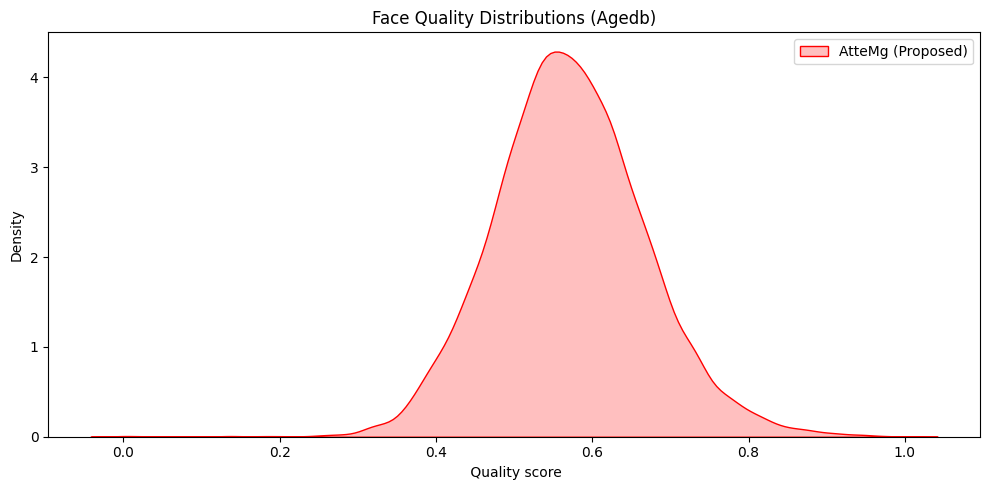

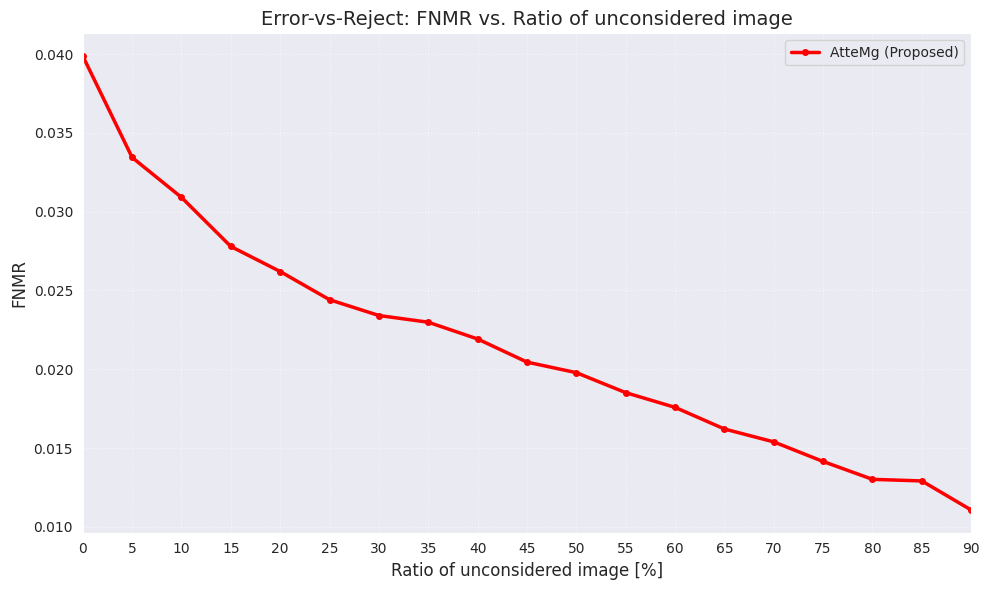

In [1]:
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. SETUP PATHS
# ==========================================
EMB_PATH = "/slurm/homes/bel/FIQX/data/agedb/embeddings/AtteMg_embeddings.pkl"
QUAL_PATH = "/slurm/homes/bel/FIQX/data/agedb/embeddings/agedb-quality.pkl"
PAIRS_CSV = "/slurm/homes/bel/FIQX/data/agedb/pairs/pairs.csv"


RESULT_DIR = "/slurm/homes/bel/FIQX/data/_results"
os.makedirs(RESULT_DIR, exist_ok=True)

# ==========================================
# 2. LOAD DATA & SIMILARITIES
# ==========================================
print("--> Loading saved embeddings and scores...")
with open(EMB_PATH, 'rb') as f: embs = pickle.load(f)
with open(QUAL_PATH, 'rb') as f: our_quals = pickle.load(f)
df_pairs = pd.read_csv(PAIRS_CSV)

sims, labels, pairs_list = [], [], []

for _, row in df_pairs.iterrows():
    f1, f2, lbl = str(row['img1']), str(row['img2']), int(row['label'])
    if f1 in embs and f2 in embs:
        v1, v2 = embs[f1], embs[f2]
        s = np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))
        sims.append(s); labels.append(lbl); pairs_list.append((f1, f2))

sims = np.array(sims)
labels = np.array(labels)

if len(sims) == 0:
    print("ERROR: No pairs found. Check your CSV and Folder filenames!")
else:
    print(f"--> Found {len(sims)} valid pairs.")
    # Calculate global threshold at FMR = 0.1%
    imposters = sims[labels == 0]
    global_thresh = np.percentile(imposters, 99.9)
    print(f"--> Threshold for FMR=10^-3: {global_thresh:.4f}")

# ==========================================
# 3. PERFORMANCE LOGIC
# ==========================================
def get_evr_curve(q_dict):
    pair_q = np.array([min(q_dict.get(f1, 0), q_dict.get(f2, 0)) for f1, f2 in pairs_list])
    idx = np.argsort(pair_q)
    ratios = np.arange(0, 95, 5)
    fnmrs = []
    for r in ratios:
        cut = int(len(pair_q) * (r / 100.0))
        rem_sims = sims[idx][cut:]
        rem_labels = labels[idx][cut:]
        genuines = rem_sims[rem_labels == 1]
        if len(genuines) == 0:
            fnmrs.append(0.0)
        else:
            # Calculate FNMR
            fnmrs.append(np.mean(genuines < global_thresh))
    return ratios, np.array(fnmrs)

# ==========================================
# 4. PLOTTING
# ==========================================
# --- FIGURE 1: DISTRIBUTION ---
print("--> Plotting Quality Distribution...")
plt.figure(figsize=(10, 5))
def norm(v): 
    v_arr = np.array(list(v.values()))
    return (v_arr - v_arr.min()) / (v_arr.max() - v_arr.min())

sns.kdeplot(norm(our_quals), label="AtteMg (Proposed)", fill=True, color='red')


plt.title("Face Quality Distributions (Agedb)")
plt.xlabel(" Quality score"); plt.legend(); plt.tight_layout()
plt.savefig(os.path.join(RESULT_DIR, "dist.png"))

# --- FIGURE 2: PERFORMANCE (EVR) ---
print("--> Plotting Performance (EVR) Curve...")
plt.figure(figsize=(10, 6))
sns.set_style("darkgrid")

r_ax, fnmr_ours = get_evr_curve(our_quals)
print(f"Proposed FNMR (Start: {fnmr_ours[0]:.4f}, End: {fnmr_ours[-1]:.4f})")
plt.plot(r_ax, fnmr_ours, 'r-o', label='AtteMg (Proposed)', linewidth=2.5, markersize=4)



# --- AXES SETUP (AUTOMATIC Y-LIMITS) ---
plt.title("Error-vs-Reject: FNMR vs. Ratio of unconsidered image", fontsize=14)
plt.xlabel("Ratio of unconsidered image [%]", fontsize=12)
plt.ylabel("FNMR", fontsize=12)
plt.xticks(np.arange(0, 95, 5))
plt.xlim(0, 90)

# Removed the hardcoded 0.01 limit so you can see your data
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper right')
plt.tight_layout()
plt.savefig(os.path.join(RESULT_DIR, "evr_agedb.png"), dpi=300)

print(f"\nSUCCESS! Figures saved in: {RESULT_DIR}")
plt.show()